# Exploratory Data Analysis - VentureSurvive

This notebook performs exploratory data analysis on the startups dataset to understand:
- Data structure and quality
- Target variable distribution
- Feature distributions and relationships
- Missing values patterns
- Preliminary insights for modeling


In [1]:
# Imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Path to the raw file
DATA_PATH = "../data/startups_raw.csv"
print("Setup complete. Ready to load data.")


Setup complete. Ready to load data.


## 1. Data loading

Load the raw dataset and look at basic information.

In [2]:
# Load the dataset

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")

# Display first few rows
display(df_raw.head())


Dataset loaded successfully!
Shape: 66,368 rows × 14 columns

Column names:
['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at']


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [3]:
# Dataset info and basic statistics

print("Dataset Information:")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("Basic Statistics (numeric columns):")
print("=" * 60)
display(df_raw.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB

Basic Statistics (numeric columns):


,funding_rounds
count,66368.000000
mean,1.732522
std,1.360251
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,19.000000


## 2. Status distribution in raw data

Look at the distribution of startup statuses in the full dataset.

Status Distribution (all data):


,Count,Percentage
status,,
operating,53034,79.91
closed,6238,9.40
acquired,5549,8.36
ipo,1547,2.33


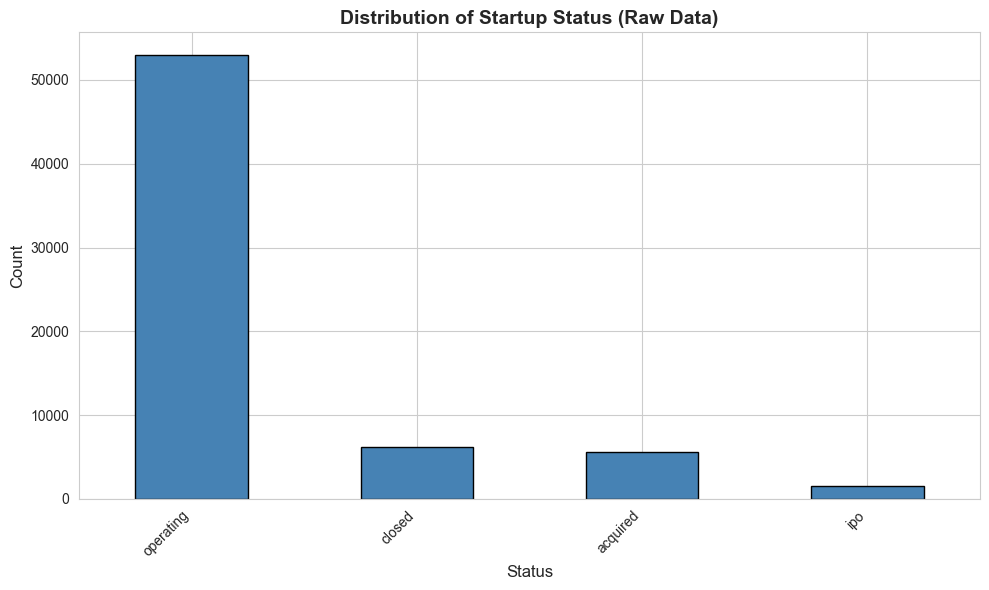

In [4]:
# Status distribution in raw data

print("Status Distribution (all data):")
print("=" * 60)
status_counts = df_raw["status"].value_counts()
status_pct = df_raw["status"].value_counts(normalize=True) * 100

status_df = pd.DataFrame({
    "Count": status_counts,
    "Percentage": status_pct.round(2)
})
display(status_df)

# Visualize status distribution
fig, ax = plt.subplots(figsize=(10, 6))
status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Distribution of Startup Status (Raw Data)", fontsize=14, fontweight='bold')
ax.set_xlabel("Status", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Definition of Success

In this project we define a binary target variable `success` that captures whether a startup either survives for at least 5 years or reaches a clear exit event.

- `years_alive` is the number of years between the founding date and the last observed date for the company.
- `survived_5y` is a boolean flag equal to `True` if `years_alive ≥ 5`.
- `success` is the main target variable and is defined as:

  - `success = 1` if `years_alive ≥ 5` **or** `status` is in `{"acquired", "ipo"}`
  - `success = 0` otherwise

In this raw dataset we approximate the last observed date using the latest available funding date (e.g. `last_funding_at`) when an explicit `closed_on` or scrape date is not present. This gives us a reasonable proxy for how long a startup has been active when performing exploratory analysis.

In [ ]:
# Compute years_alive, survived_5y, and success

# Make a working copy to avoid accidental modification of df_raw in earlier cells
eda_df = df_raw.copy()

# Convert relevant date columns to datetime if present
for col in ["founded_at", "first_funding_at", "last_funding_at"]:
    if col in eda_df.columns:
        eda_df[col] = pd.to_datetime(eda_df[col], errors="coerce")

# Initialize columns with NaN so the notebook runs even if some date columns are missing
eda_df["years_alive"] = np.nan
eda_df["survived_5y"] = np.nan
eda_df["success"] = np.nan

if {"founded_at", "first_funding_at", "last_funding_at"}.issubset(eda_df.columns):
    # Use the latest available funding date as a proxy for last observed date
    end_date = eda_df["last_funding_at"].fillna(eda_df["first_funding_at"])

    # Compute years_alive in years
    mask_valid = eda_df["founded_at"].notna() & end_date.notna()
    eda_df.loc[mask_valid, "years_alive"] = (
        (end_date[mask_valid] - eda_df.loc[mask_valid, "founded_at"]).dt.days / 365.25
    )

    # survived_5y: True if years_alive >= 5
    eda_df.loc[mask_valid, "survived_5y"] = eda_df.loc[mask_valid, "years_alive"] >= 5

# Define success using years_alive and exit status where possible
if "status" in eda_df.columns:
    exit_mask = eda_df["status"].isin(["acquired", "ipo"])
    long_lived_mask = eda_df["years_alive"].ge(5)

    # Combine conditions; .fillna(False) ensures missing years_alive does not cause errors
    success_series = exit_mask | long_lived_mask.fillna(False)
    eda_df["success"] = success_series.astype(int)

print("New columns added:")
for col in ["years_alive", "survived_5y", "success"]:
    if col in eda_df.columns:
        print(f"  - {col}")

eda_df[["status", "years_alive", "survived_5y", "success"]].head()

### 3.1 Distributions of `years_alive` and `success`

We now look at how long startups tend to live (in years) and how the new binary target `success` is distributed in the raw data.

In [ ]:
# Distribution of years_alive

if "years_alive" in eda_df.columns:
    print("Summary statistics for years_alive (in years):")
    print("=" * 60)
    display(eda_df["years_alive"].describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(eda_df["years_alive"].dropna(), bins=50, kde=False, color="steelblue")
    plt.title("Distribution of Years Alive", fontsize=14, fontweight="bold")
    plt.xlabel("Years alive")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'years_alive' not available; skipping distribution plot.")

# Distribution of success
if "success" in eda_df.columns:
    print("\nDistribution of success (0 = not successful, 1 = successful):")
    print("=" * 60)
    success_counts = eda_df["success"].value_counts(dropna=False).sort_index()
    success_pct = eda_df["success"].value_counts(normalize=True, dropna=False).sort_index() * 100

    success_df = pd.DataFrame({
        "Count": success_counts,
        "Percentage": success_pct.round(2)
    })
    display(success_df)

    plt.figure(figsize=(6, 5))
    success_counts.plot(kind="bar", color=["salmon", "seagreen"], edgecolor="black")
    plt.title("Distribution of Success Target", fontsize=14, fontweight="bold")
    plt.xlabel("success (0 = no, 1 = yes)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'success' not available; skipping distribution plot.")

### 3.2 Relationship between `success` and key features

Here we take a quick look at how the new `success` target relates to a few important features such as total funding and region. These are high-level exploratory views, not final modeling features.

In [ ]:
# Relationship between success and funding_total_usd

if {"success", "funding_total_usd"}.issubset(eda_df.columns):
    # Convert funding_total_usd to numeric for plotting
    eda_df["funding_total_usd_num"] = pd.to_numeric(eda_df["funding_total_usd"], errors="coerce")

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=eda_df.dropna(subset=["funding_total_usd_num", "success"]),
        x="success",
        y="funding_total_usd_num"
    )
    plt.yscale("log")
    plt.title("Funding vs. Success (log scale)", fontsize=14, fontweight="bold")
    plt.xlabel("success (0 = no, 1 = yes)")
    plt.ylabel("Total funding (USD, log scale)")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for funding vs success plot not available.")

# Relationship between success rate and region (top regions)
if {"success", "region"}.issubset(eda_df.columns):
    region_success = (
        eda_df.dropna(subset=["region", "success"])
        .groupby("region")["success"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 6))
    region_success.plot(kind="bar", color="steelblue", edgecolor="black")
    plt.title("Success Rate by Region (Top 15)", fontsize=14, fontweight="bold")
    plt.xlabel("Region")
    plt.ylabel("Mean success rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for region vs success plot not available.")

### 3.3 Note on target for modeling

Downstream modeling notebooks will use the binary `success` variable defined above as the main target, instead of predicting the raw `status` field directly. This allows us to capture both long-term survival (≥ 5 years) and clear exit events (`acquired` or `ipo`) in a single outcome variable.